In [1]:
import numpy as np
import os, sys 
import re
import ROOT
ROOT.gStyle.SetOptStat(0)
import array
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import glob
import pandas as pd

import matplotlib.pyplot as plt
from linearization import linearization
import read_relcal
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

Welcome to JupyROOT 6.28/10


In [2]:
## R37 Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', '23240108_203134', '23231221_101235', '23231221_015705', '23231220_190923', '23231220_122140', '23231220_053358', '23231220_012745', '23231219_184002', 
             '23231219_110331', '23231219_034952', '23231218_223530', '23231218_190035', '23231218_152721', '23231218_093255', '23231218_024511', '23231217_212512', '23231217_171613', '23231217_135018', 
             '23231216_233807', '23231216_211119', '23231216_194929', '23231216_182937', '23231216_173436', '23231216_145300', '23231216_100125', '23231216_043946', '23231216_013604']
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [3]:
## Use DataCat to pull the series
dc = CDMSDataCatalog().findData(
    Facility    = "CUTE",
    nFridgeRun  = 37,
    Series      = series_list,
    ProdTag     = ProdTag,
    nMergeLevel = 1,
    dofetch     = True
)
RQfiles_data = [x.filePath for x in dc]

In [4]:
fp = "/project/6049244/share/SimData/DMC_SNOLAB_HV/" ## this is the global file path the DMC data is saved in on compute canada

## Define the filepaths used
samples = {"L": "Ge71_Lshell_pos50V_V05-09",
           "K": "Ge71_Kshell_pos50V_100kEvents_V05-09"}
truth =   {"L": "/DMCOutput/*.root",
           "K": "/DMCOutput/R*/*.root"}
proc =    {"L": "/Processed/Unmerged/*/*.root",
           "K": "/Processed/R*/Unmerged/*/*.root"}

In [5]:
## Get the file names in these folders
RQfiles_K, RQfiles_L       = np.sort(glob.glob(fp+samples["K"]+proc["K"])), np.sort(glob.glob(fp+samples["L"]+proc["L"]))
truthfiles_K, truthfiles_L = np.sort(glob.glob(fp+samples["K"]+truth["K"])), np.sort(glob.glob(fp+samples["L"]+truth["L"]))

 ## simulation truth
DMChit_K = CDataFrame("G4SimDir/g4dmcHits", truthfiles_K)
DMCevent_K = CDataFrame("G4SimDir/g4dmcEvent", truthfiles_K)
DMChit_L = CDataFrame("G4SimDir/g4dmcHits", truthfiles_L)
DMCevent_L = CDataFrame("G4SimDir/g4dmcEvent", truthfiles_L)

In [6]:
config_path = "/scratch/perry/processing/cdmsbats_config/UserSettings/BatRootSettings/analysis/"
config_sim = "DMCData.HV100mm_uni_triangle"
config_data = "configCUTEData.NxM.50VZ1Z30VZ6.V4.0.0"
relcal_path = {'sim':  config_path+config_sim,
               'data': config_path+config_data}

det     = {'sim': 1, 'data': 1}
trigdet = {'sim': 0, 'data': 1}

In [7]:
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQ_branches = ["SeriesNumber", "EventNumber", "PTOFamps", "EventTriggerID"] + [chan + "OFamps" for chan in channels]
DMC_branches = ["EventNum", "X", "Y", "Z"]
keVt2keVee = 1/(1 + 50/3) # inverse of Luke gain factor
lin2keVee = {'sim': 210e2 * keVt2keVee, 'data': 210e2 * keVt2keVee} # (keVt/linAmp) * (keVee / keVt)
RQs = {}

In [8]:
## load relevant RQs for data
df = CDataFrame("rqDir/zip"+str(det["data"]), RQfiles_data, friends = [[x+":rqDir/eventTree" for x in RQfiles_data]])
    
## Apply some basic data quality filters and get the RQs you're interested in
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["data"]), "PTOFamps>0"])
RQs["data"] = df_filtered.AsNumpy(RQ_branches)

## linearize and calibrate PTOFamps to keVee
lin_class = linearization(det["data"], 'PTOFamps', 'unbinned')
RQs["data"]['lin_PTOFamps'] = lin_class.linearize(RQs["data"]['PTOFamps'])
RQs["data"]['calib_PTOFamps'] = RQs["data"]['lin_PTOFamps'] * lin2keVee["data"]

In [9]:
## load relevant RQs for simulation
df_K = CDataFrame("rqDir/zip"+str(det["sim"]), RQfiles_K, friends = [[x+":rqDir/eventTree" for x in RQfiles_K]])
df_L = CDataFrame("rqDir/zip"+str(det["sim"]), RQfiles_L, friends = [[x+":rqDir/eventTree" for x in RQfiles_L]])
    
## Apply some basic data quality filters and get the RQs you're interested in
df_K_filtered = df_K.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["sim"]), "PTOFamps>0"])
df_L_filtered = df_L.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["sim"]), "PTOFamps>0"])
RQs_K = df_K_filtered.Filter(f"EventTriggerID<{int((87.57/10.53)*1e4)}").AsNumpy(RQ_branches) # get correct ratio between L and K events. Use the fact that L shell sample has 10k events.
RQs_L = df_L_filtered.AsNumpy(RQ_branches)

# deal with CDMSSIM-451
for branch in channels + ['PT']:
    RQs_K[branch + 'OFamps'] *= 10/4
    RQs_L[branch + 'OFamps'] *= 10/4

# combine truth data with RQs
hits_K = pd.DataFrame(DMChit_K.Filter(f"EventNum<{int((87.57/10.53)*1e4)}").AsNumpy(DMC_branches))
hits_L = pd.DataFrame(DMChit_L.AsNumpy(DMC_branches))

events_K = DMCevent_K.Filter(f"EventNum<{int((87.57/10.53)*1e4)}").AsNumpy(['EventNum', 'PhononE'])
events_L = DMCevent_L.AsNumpy(['EventNum', 'PhononE'])

events_K['PhononE'] = list(events_K['PhononE'])
events_L['PhononE'] = list(events_L['PhononE'])

events_K = pd.DataFrame(events_K)
events_L = pd.DataFrame(events_L)

hits_K = hits_K.rename(columns={'EventNum': 'EventTriggerID'})
hits_L = hits_L.rename(columns={'EventNum': 'EventTriggerID'})
events_K = events_K.rename(columns={'EventNum': 'EventTriggerID'})
events_L = events_L.rename(columns={'EventNum': 'EventTriggerID'})

# Construct and return the single dataframe with the info we care about
merged_K = pd.merge(pd.DataFrame(RQs_K), hits_K, on='EventTriggerID', how='inner')
merged_K = pd.merge(merged_K, events_K, on='EventTriggerID', how='inner')
merged_L = pd.merge(pd.DataFrame(RQs_L), hits_L, on='EventTriggerID', how='inner')
merged_L = pd.merge(merged_L, events_L, on='EventTriggerID', how='inner')
merged = pd.concat([merged_L, merged_K], ignore_index=True)
merged = merged.to_dict(orient='list')
merged ={key: np.array(value) for key, value in merged.items()}

RQs['sim'] = merged

## linearize and calibrate PTOFamps to keVee
lin_class = linearization(det["sim"], 'PTOFamps', 'unbinned')
RQs["sim"]['lin_PTOFamps'] = lin_class.linearize(RQs["sim"]['PTOFamps'])
RQs["sim"]['calib_PTOFamps'] = RQs["sim"]['lin_PTOFamps'] * lin2keVee["sim"]

In [10]:
## Calculate radial parameter from channel amplitudes
for datatype in ['data', 'sim']:
    rel_calibs = read_relcal.get_rel_calib(relcal_path[datatype])
    Fsum = RQs[datatype]['PFS1OFamps']*rel_calibs[det[datatype]]['PFS1'] + RQs[datatype]['PFS2OFamps']*rel_calibs[det[datatype]]['PFS2']
    Asum = RQs[datatype]['PAS1OFamps']*rel_calibs[det[datatype]]['PAS1'] + RQs[datatype]['PAS2OFamps']*rel_calibs[det[datatype]]['PAS2']
    RQs[datatype]['RadialPar'] = (Fsum - Asum) / RQs[datatype]['PTOFamps']

In [11]:
## Set of cuts for selecting events in different regions of the Ge-71 spectrum. Bounds often set by the +/-3 sigma edges of the peaks. Fit results taken from here:
# https://confluence.slac.stanford.edu/spaces/CDMS/pages/601696559/Comparing+Ge+activation+rates+in+data+and+simulation
bounds = {'sim': {'K': {'lower': 9.9632 - 3*0.1209,
                        'upper': 9.9632 + 3*0.1209},
                  'L': {'lower': 1.2512 - 3*0.0240,
                        'upper': 1.2512 + 3*0.0240}},
          'data':{'K': {'lower': 10.08 - 3*0.23,
                        'upper': 10.63 + 3*0.2},
                  'L': {'lower': 1.280 - 3*0.063,
                        'upper': 1.280 + 3*0.063}}}

## Events inside +/- 3 sigma of the K shell peak.
RQs['sim']['Kshell_cut']  = (RQs['sim']['calib_PTOFamps'] < bounds['sim']['K']['upper']) & (RQs['sim']['calib_PTOFamps'] > bounds['sim']['K']['lower'])
RQs['data']['Kshell_cut'] = (RQs['data']['calib_PTOFamps'] < bounds['data']['K']['upper']) & (RQs['data']['calib_PTOFamps'] > bounds['data']['K']['lower'])

## Events inside the Ge-71 spectrum. Everything between -3 sigma of the L shell and +3 sigma of the K shell peaks.
RQs['sim']['Ge71_cut']  = (RQs['sim']['calib_PTOFamps'] < bounds['sim']['K']['upper']) & (RQs['sim']['calib_PTOFamps'] > bounds['sim']['L']['lower'])
RQs['data']['Ge71_cut'] = (RQs['data']['calib_PTOFamps'] < bounds['data']['K']['upper']) & (RQs['data']['calib_PTOFamps'] > bounds['data']['L']['lower'])

In [12]:
R = np.sqrt( (RQs['sim']['X']*1e3)**2 + (RQs['sim']['Y']*1e3)**2 )

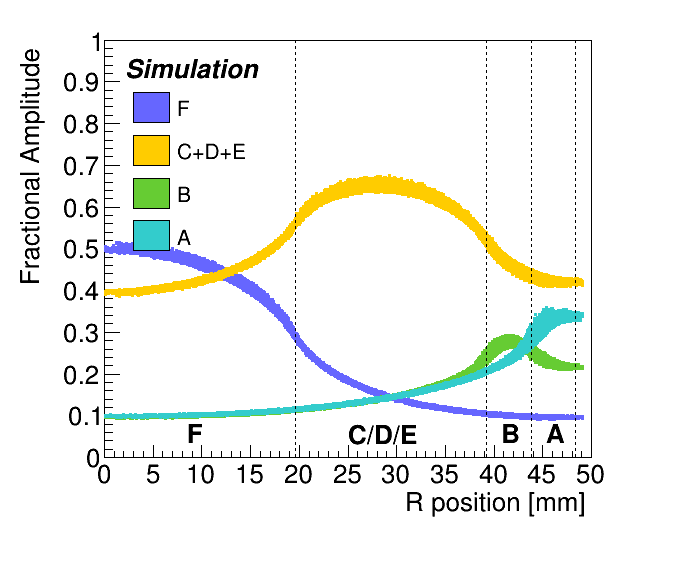

In [13]:
scatter_sim = ROOplot(700, 600, _xlabel="R position [mm]", _ylabel="Fractional Amplitude", _ylim=True, _ylow=0, _yhigh=1, _xlim=True, _xlow=0, _xhigh=50)

cut = RQs['sim']['Kshell_cut']
rel_calibs = read_relcal.get_rel_calib(relcal_path['sim'])
RadialPar = RQs['sim']['RadialPar']
Fsum = (RQs['sim']['PFS1OFamps']*rel_calibs[1]['PFS1'] + RQs['sim']['PFS2OFamps']*rel_calibs[1]['PFS2'])
wedgesum = (RQs['sim']['PES1OFamps']*rel_calibs[1]['PES1'] + RQs['sim']['PES2OFamps']*rel_calibs[1]['PES2'] +
            RQs['sim']['PDS1OFamps']*rel_calibs[1]['PDS1'] + RQs['sim']['PDS2OFamps']*rel_calibs[1]['PDS2'] + 
            RQs['sim']['PCS1OFamps']*rel_calibs[1]['PCS1'] + RQs['sim']['PCS2OFamps']*rel_calibs[1]['PCS2'])
Bsum = (RQs['sim']['PBS1OFamps']*rel_calibs[1]['PBS1'] + RQs['sim']['PBS2OFamps']*rel_calibs[1]['PBS2'])
Asum = (RQs['sim']['PAS1OFamps']*rel_calibs[1]['PAS1'] + RQs['sim']['PAS2OFamps']*rel_calibs[1]['PAS2'])
PTOFamps = RQs['sim']['PTOFamps']

scatter_sim.createScatter(R[cut], (Fsum / PTOFamps)[cut], color = ROOT.kBlue-7, size = 0.4, label = "F")
scatter_sim.createScatter(R[cut], (wedgesum / PTOFamps)[cut], color = ROOT.kOrange, size = 0.4, label = "C+D+E")
scatter_sim.createScatter(R[cut], (Bsum / PTOFamps)[cut], color = ROOT.kSpring-5, size = 0.4, label = "B")
scatter_sim.createScatter(R[cut], (Asum / PTOFamps)[cut], color = ROOT.kCyan-3, size = 0.4, label = "A")
scatter_sim.draw("AP", "P ")

graphs = scatter_sim.getGraphs()

legend = ROOT.TLegend(0.18, 0.55, 0.48, 0.85)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{Simulation}"
latex.DrawLatex(0.18, 0.9, text)

latex.DrawLatex(0.27, 0.26, "F")
latex.DrawLatex(0.5, 0.26, "C/D/E")
latex.DrawLatex(0.72, 0.26, "B")
latex.DrawLatex(0.785, 0.26, "A")

lineF = ROOT.TLine(19.592, 0, 19.592, 1)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, 0, 39.192, 1)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, 0, 43.818, 1)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, 0, 48.3, 1)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


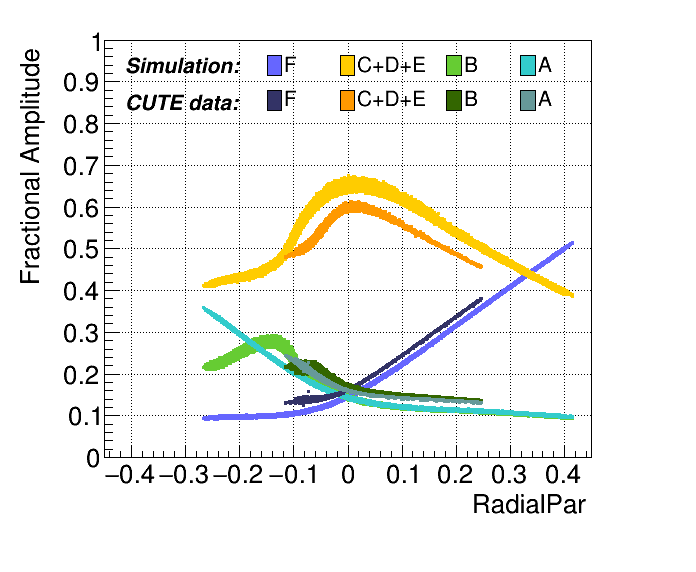

In [14]:
scatter_sim = ROOplot(700, 600, _xlabel="RadialPar", _ylabel="Fractional Amplitude", _ylim=True, _ylow=0, _yhigh=1, _xlim=True, _xlow=-0.45, _xhigh=0.45)

cut = RQs['sim']['Kshell_cut']
rel_calibs = read_relcal.get_rel_calib(relcal_path['sim'])
RadialPar = RQs['sim']['RadialPar']
Fsum = (RQs['sim']['PFS1OFamps']*rel_calibs[1]['PFS1'] + RQs['sim']['PFS2OFamps']*rel_calibs[1]['PFS2'])
wedgesum = (RQs['sim']['PES1OFamps']*rel_calibs[1]['PES1'] + RQs['sim']['PES2OFamps']*rel_calibs[1]['PES2'] +
            RQs['sim']['PDS1OFamps']*rel_calibs[1]['PDS1'] + RQs['sim']['PDS2OFamps']*rel_calibs[1]['PDS2'] + 
            RQs['sim']['PCS1OFamps']*rel_calibs[1]['PCS1'] + RQs['sim']['PCS2OFamps']*rel_calibs[1]['PCS2'])
Bsum = (RQs['sim']['PBS1OFamps']*rel_calibs[1]['PBS1'] + RQs['sim']['PBS2OFamps']*rel_calibs[1]['PBS2'])
Asum = (RQs['sim']['PAS1OFamps']*rel_calibs[1]['PAS1'] + RQs['sim']['PAS2OFamps']*rel_calibs[1]['PAS2'])
PTOFamps = RQs['sim']['PTOFamps']

scatter_sim.createScatter(RadialPar[cut], (Fsum / PTOFamps)[cut], color = ROOT.kBlue-7, size = 0.4, label = "F" + " "*4)
scatter_sim.createScatter(RadialPar[cut], (wedgesum / PTOFamps)[cut], color = ROOT.kOrange, size = 0.4, label = "C+D+E")
scatter_sim.createScatter(RadialPar[cut], (Bsum / PTOFamps)[cut], color = ROOT.kSpring-5, size = 0.4, label = "B" + " "*4)
scatter_sim.createScatter(RadialPar[cut], (Asum / PTOFamps)[cut], color = ROOT.kCyan-3, size = 0.4, label = "A" + " "*4)

cut = RQs['data']['Kshell_cut']
rel_calibs = read_relcal.get_rel_calib(relcal_path['data'])
RadialPar = RQs['data']['RadialPar']
Fsum = (RQs['data']['PFS1OFamps']*rel_calibs[1]['PFS1'] + RQs['data']['PFS2OFamps']*rel_calibs[1]['PFS2'])
wedgesum = (RQs['data']['PES1OFamps']*rel_calibs[1]['PES1'] + RQs['data']['PES2OFamps']*rel_calibs[1]['PES2'] +
            RQs['data']['PDS1OFamps']*rel_calibs[1]['PDS1'] + RQs['data']['PDS2OFamps']*rel_calibs[1]['PDS2'] + 
            RQs['data']['PCS1OFamps']*rel_calibs[1]['PCS1'] + RQs['data']['PCS2OFamps']*rel_calibs[1]['PCS2'])
Bsum = (RQs['data']['PBS1OFamps']*rel_calibs[1]['PBS1'] + RQs['data']['PBS2OFamps']*rel_calibs[1]['PBS2'])
Asum = (RQs['data']['PAS1OFamps']*rel_calibs[1]['PAS1'] + RQs['data']['PAS2OFamps']*rel_calibs[1]['PAS2'])
PTOFamps = RQs['data']['PTOFamps']

scatter_sim.createScatter(RadialPar[cut], (Fsum / PTOFamps)[cut], color = ROOT.kBlue-1, size = 0.4, label = "F" + " "*4)
scatter_sim.createScatter(RadialPar[cut], (wedgesum / PTOFamps)[cut], color = ROOT.kOrange-3, size = 0.4, label = "C+D+E")
scatter_sim.createScatter(RadialPar[cut], (Bsum / PTOFamps)[cut], color = ROOT.kSpring-7, size = 0.4, label = "B" + " "*4)
scatter_sim.createScatter(RadialPar[cut], (Asum / PTOFamps)[cut], color = ROOT.kCyan-5, size = 0.4, label = "A" + " "*4)

scatter_sim.draw("AP", "P ", grid=True)

graphs = scatter_sim.getGraphs()

legend1 = ROOT.TLegend(0.38, 0.86, 0.85, 0.91)
legend1.SetBorderSize(0)
legend1.SetFillStyle(0)
legend1.SetTextSize(0.04)
legend1.SetNColumns(4)
for g, label in graphs[:4]:
    legend1.AddEntry(g, label, "f")

legend2 = ROOT.TLegend(0.38, 0.8, 0.85, 0.85)
legend2.SetBorderSize(0)
legend2.SetFillStyle(0)
legend2.SetTextSize(0.04)
legend2.SetNColumns(4)
for g, label in graphs[4:]:
    legend2.AddEntry(g, label, "f")

legend1.Draw()
legend2.Draw()

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.04)
latex.SetTextAlign(13)
text = "#font[72]{Simulation:}"
latex.DrawLatex(0.18, 0.9, text)

text = "#font[72]{CUTE data:}"
latex.DrawLatex(0.18, 0.835, text)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


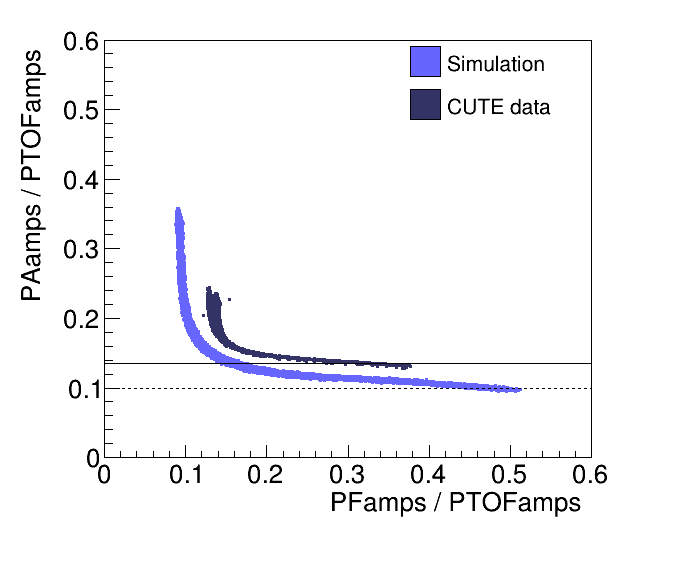

In [15]:
scatter_sim = ROOplot(700, 600, _xlabel="PFamps / PTOFamps", _ylabel="PAamps / PTOFamps", _xlim=True, _xlow=0, _xhigh=0.6, _ylim=True, _ylow=0, _yhigh=0.6)

cut = RQs['sim']['Kshell_cut']
rel_calibs = read_relcal.get_rel_calib(relcal_path['sim'])
RadialPar = RQs['sim']['RadialPar']
Fsum = (RQs['sim']['PFS1OFamps']*rel_calibs[1]['PFS1'] + RQs['sim']['PFS2OFamps']*rel_calibs[1]['PFS2'])
Asum = (RQs['sim']['PAS1OFamps']*rel_calibs[1]['PAS1'] + RQs['sim']['PAS2OFamps']*rel_calibs[1]['PAS2'])
PTOFamps = RQs['sim']['PTOFamps']

scatter_sim.createScatter((Fsum / PTOFamps)[cut], (Asum / PTOFamps)[cut], color = ROOT.kBlue-7, size = 0.4, label = "Simulation")

cut = RQs['data']['Kshell_cut']
rel_calibs = read_relcal.get_rel_calib(relcal_path['data'])
RadialPar = RQs['data']['RadialPar']
Fsum = (RQs['data']['PFS1OFamps']*rel_calibs[1]['PFS1'] + RQs['data']['PFS2OFamps']*rel_calibs[1]['PFS2'])
Asum = (RQs['data']['PAS1OFamps']*rel_calibs[1]['PAS1'] + RQs['data']['PAS2OFamps']*rel_calibs[1]['PAS2'])
PTOFamps = RQs['data']['PTOFamps']

scatter_sim.createScatter((Fsum / PTOFamps)[cut], (Asum / PTOFamps)[cut], color = ROOT.kBlue-1, size = 0.4, label = "CUTE data")

scatter_sim.draw("AP", "P ", grid=False)

line1 = ROOT.TLine(0, 0.1, 0.6, 0.1)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(2)
line1.SetLineWidth(1)
line1.Draw("same")

line2 = ROOT.TLine(0, 0.135, 0.6, 0.135)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(1)
line2.SetLineWidth(1)
line2.Draw("same")

graphs = scatter_sim.getGraphs()

legend = ROOT.TLegend(0.58, 0.78, 0.83, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

0.12279276112794028
0.129770222013009


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


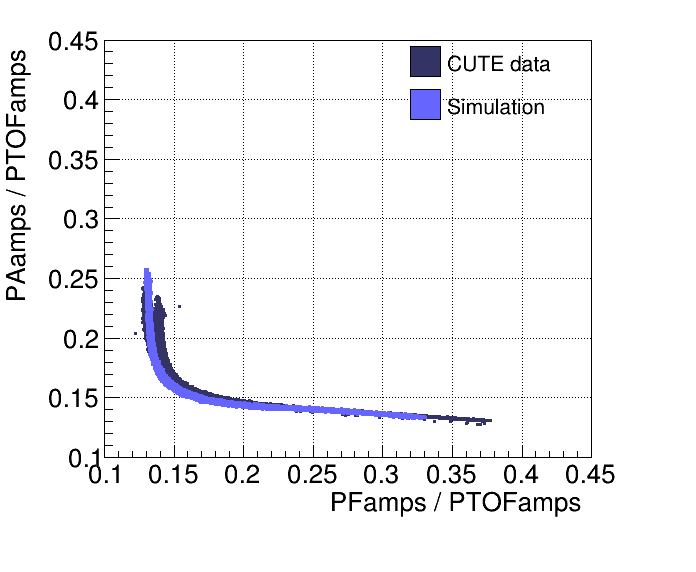

In [16]:
scatter_sim = ROOplot(700, 600, _xlabel="PFamps / PTOFamps", _ylabel="PAamps / PTOFamps", _xlim=True, _xlow=0.1, _xhigh=0.45, _ylim=True, _ylow=0.1, _yhigh=0.45)

cut = RQs['data']['Kshell_cut']
rel_calibs = read_relcal.get_rel_calib(relcal_path['data'])
RadialPar = RQs['data']['RadialPar']
Fsum = (RQs['data']['PFS1OFamps']*rel_calibs[1]['PFS1'] + RQs['data']['PFS2OFamps']*rel_calibs[1]['PFS2'])
Asum = (RQs['data']['PAS1OFamps']*rel_calibs[1]['PAS1'] + RQs['data']['PAS2OFamps']*rel_calibs[1]['PAS2'])
PTOFamps = RQs['data']['PTOFamps']

print(min((Fsum / PTOFamps)[cut]))

scatter_sim.createScatter((Fsum / PTOFamps)[cut], (Asum / PTOFamps)[cut], color = ROOT.kBlue-1, size = 0.4, label = "CUTE data")

cut = RQs['sim']['Kshell_cut']
rel_calibs = read_relcal.get_rel_calib(relcal_path['sim'])
RadialPar = RQs['sim']['RadialPar']
PTOFamps = RQs['sim']['PTOFamps']
delta = 0.04375 * PTOFamps
PFS1OFamps = delta + RQs['sim']['PFS1OFamps']*rel_calibs[1]['PFS1'] * (PTOFamps - 12 * delta) / PTOFamps
PFS2OFamps = delta + RQs['sim']['PFS2OFamps']*rel_calibs[1]['PFS2'] * (PTOFamps - 12 * delta) / PTOFamps
PAS1OFamps = delta + RQs['sim']['PAS1OFamps']*rel_calibs[1]['PAS1'] * (PTOFamps - 12 * delta) / PTOFamps
PAS2OFamps = delta + RQs['sim']['PAS2OFamps']*rel_calibs[1]['PAS2'] * (PTOFamps - 12 * delta) / PTOFamps
Fsum = PFS1OFamps + PFS2OFamps
Asum = PAS1OFamps + PAS2OFamps

print(min((Fsum / PTOFamps)[cut]))

scatter_sim.createScatter((Fsum / PTOFamps)[cut], (Asum / PTOFamps)[cut], color = ROOT.kBlue-7, size = 0.4, label = "Simulation")

scatter_sim.draw("AP", "P ", grid=True)

graphs = scatter_sim.getGraphs()

legend = ROOT.TLegend(0.58, 0.78, 0.83, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


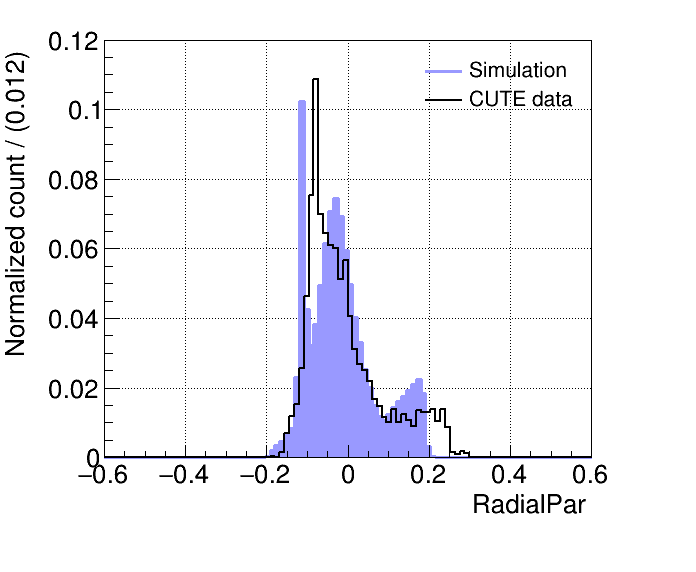

In [63]:
bins_start, bins_end, nbins = -0.6, 0.6, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.12)

hist.createHist(RQs['sim']['RadialPar'][RQs['sim']['Kshell_cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kBlue-9, fillstyle=1001, scale=sum(RQs['sim']['Kshell_cut']), label="Simulation")
hist.createHist(RQs['data']['RadialPar'][RQs['data']['Kshell_cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, scale=sum(RQs['data']['Kshell_cut']), label="CUTE data")

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.6, 0.8, 0.9, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


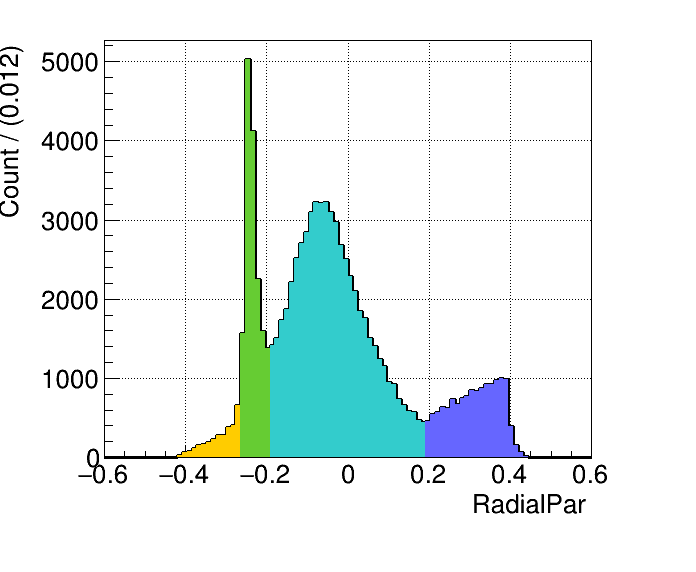

In [14]:
bins_start, bins_end, nbins = -0.6, 0.6, 100
bin_edges = np.linspace(bins_start, bins_end, nbins + 1)
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Count / (" + str(binwidth) + ")")

hist.createHist(RQs['sim']['RadialPar'][RQs['sim']['Ge71_cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kBlack)

cut = (RQs['sim']['Ge71_cut']) & (RQs['sim']['RadialPar'] < bin_edges[28])
hist.createHist(RQs['sim']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kOrange)

cut = (RQs['sim']['Ge71_cut']) & (RQs['sim']['RadialPar'] >= bin_edges[28]) & (RQs['sim']['RadialPar'] < bin_edges[34])
hist.createHist(RQs['sim']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kSpring-5)

cut = (RQs['sim']['Ge71_cut']) & (RQs['sim']['RadialPar'] >= bin_edges[34]) & (RQs['sim']['RadialPar'] < bin_edges[66])
hist.createHist(RQs['sim']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kCyan-3)

cut = (RQs['sim']['Ge71_cut']) & (RQs['sim']['RadialPar'] >= bin_edges[66])
hist.createHist(RQs['sim']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kBlue-7)

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


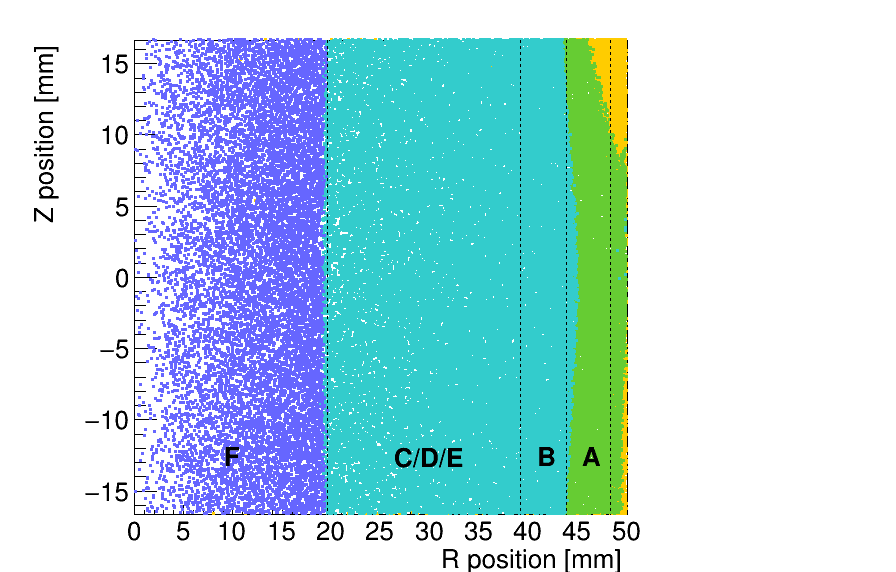

In [15]:
scatter_sim = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _rightMargin=0.3, _leftMargin=0.15, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=33.33/2)

cut = (RQs['sim']['Ge71_cut']) & (RQs['sim']['RadialPar'] < bin_edges[28])
scatter_sim.createScatter(np.sqrt( (RQs['sim']['X']*1e3)**2 + (RQs['sim']['Y']*1e3)**2 ), RQs['sim']['Z']*1e3, color = ROOT.kOrange, size = 0.4, label = "No cut")

cut = (RQs['sim']['Ge71_cut']) & (RQs['sim']['RadialPar'] >= bin_edges[28]) & (RQs['sim']['RadialPar'] < bin_edges[34])
scatter_sim.createScatter(np.sqrt( (RQs['sim']['X'][cut]*1e3)**2 + (RQs['sim']['Y'][cut]*1e3)**2 ), RQs['sim']['Z'][cut]*1e3, color = ROOT.kSpring-5, size = 0.4, label = "RadialPar > -0.2")

cut = (RQs['sim']['Ge71_cut']) & (RQs['sim']['RadialPar'] >= bin_edges[34]) & (RQs['sim']['RadialPar'] < bin_edges[66])
scatter_sim.createScatter(np.sqrt( (RQs['sim']['X'][cut]*1e3)**2 + (RQs['sim']['Y'][cut]*1e3)**2 ), RQs['sim']['Z'][cut]*1e3, color = ROOT.kCyan-3, size = 0.4, label = "RadialPar > -0.0")

cut = (RQs['sim']['Ge71_cut']) & (RQs['sim']['RadialPar'] >= bin_edges[66])
scatter_sim.createScatter(np.sqrt( (RQs['sim']['X'][cut]*1e3)**2 + (RQs['sim']['Y'][cut]*1e3)**2 ), RQs['sim']['Z'][cut]*1e3, color = ROOT.kBlue-7, size = 0.4, label = "RadialPar > 0.2")
scatter_sim.draw("AP", "P ")

lineF = ROOT.TLine(19.592, -33.33/2, 19.592, 33.33/2)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -33.33/2, 39.192, 33.33/2)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -33.33/2, 43.818, 33.33/2)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -33.33/2, 48.3, 33.33/2)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

latex.DrawLatex(0.25, 0.22, "F")
latex.DrawLatex(0.44, 0.22, "C/D/E")
latex.DrawLatex(0.6, 0.22, "B")
latex.DrawLatex(0.65, 0.22, "A")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


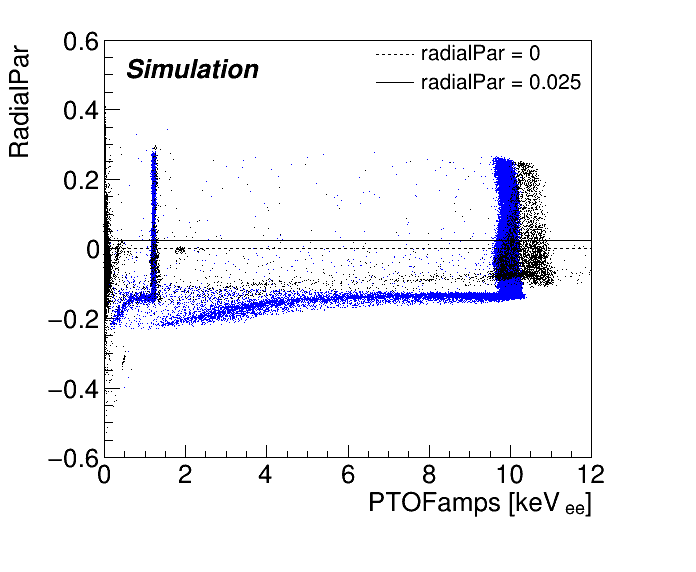

In [313]:
scatter_sim = ROOplot(_xlabel="PTOFamps [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="RadialPar", _xlim=True, _xlow=0, _xhigh=12, _ylim=True, _ylow=-0.6, _yhigh=0.6)
scatter_sim.createScatter(RQs['sim']['calib_PTOFamps'], RQs['sim']['RadialPar'])
scatter_sim.createScatter(RQs['data']['calib_PTOFamps'], RQs['data']['RadialPar'], color = ROOT.kBlack)
scatter_sim.draw("AP", "P ")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{Simulation}"
latex.DrawLatex(0.18, 0.9, text)

line1 = ROOT.TLine(0, 0, 12, 0)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(2)
line1.SetLineWidth(1)
line1.Draw("same")

line2 = ROOT.TLine(0, 0.025, 12, 0.025)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(1)
line2.SetLineWidth(1)
line2.Draw("same")

legend = ROOT.TLegend(0.53, 0.83, 0.83, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(line1, "radialPar = 0", "l")
legend.AddEntry(line2, "radialPar = 0.025", "l")
legend.SetTextSize(0.04)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


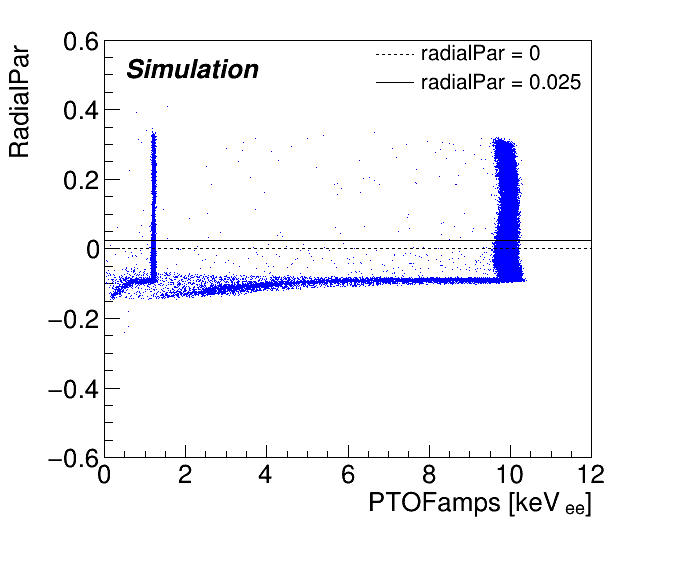

In [259]:
scatter_sim = ROOplot(_xlabel="PTOFamps [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="RadialPar", _xlim=True, _xlow=0, _xhigh=12, _ylim=True, _ylow=-0.6, _yhigh=0.6)
scatter_sim.createScatter(RQs['sim']['calib_PTOFamps'], RQs['sim']['RadialPar'])
scatter_sim.draw("AP", "P ")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{Simulation}"
latex.DrawLatex(0.18, 0.9, text)

line1 = ROOT.TLine(0, 0, 12, 0)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(2)
line1.SetLineWidth(1)
line1.Draw("same")

line2 = ROOT.TLine(0, 0.025, 12, 0.025)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(1)
line2.SetLineWidth(1)
line2.Draw("same")

legend = ROOT.TLegend(0.53, 0.83, 0.83, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(line1, "radialPar = 0", "l")
legend.AddEntry(line2, "radialPar = 0.025", "l")
legend.SetTextSize(0.04)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


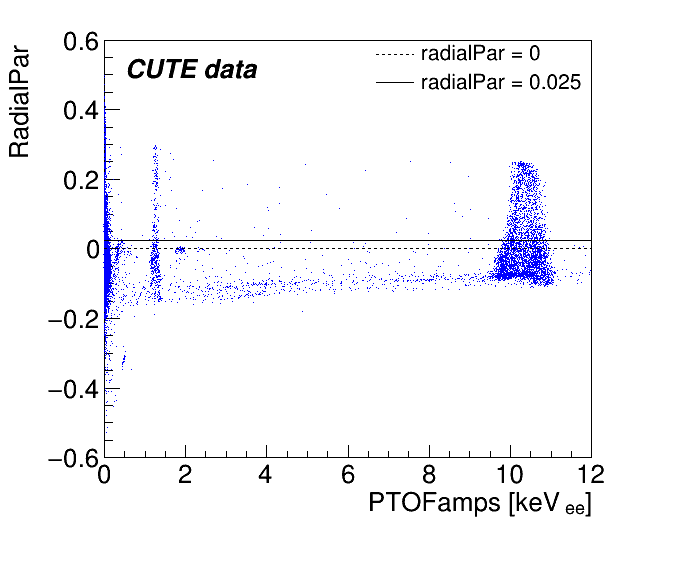

In [260]:
scatter_data = ROOplot(_xlabel="PTOFamps [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="RadialPar", _xlim=True, _xlow=0, _xhigh=12, _ylim=True, _ylow=-0.6, _yhigh=0.6)
scatter_data.createScatter(RQs['data']['calib_PTOFamps'], RQs['data']['RadialPar'])
scatter_data.draw("AP", "P ")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{CUTE data}"
latex.DrawLatex(0.18, 0.9, text)

line1 = ROOT.TLine(0, 0, 12, 0)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(2)
line1.SetLineWidth(1)
line1.Draw("same")

line2 = ROOT.TLine(0, 0.025, 12, 0.025)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(1)
line2.SetLineWidth(1)
line2.Draw("same")

legend = ROOT.TLegend(0.53, 0.83, 0.83, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(line1, "radialPar = 0", "l")
legend.AddEntry(line2, "radialPar = 0.025", "l")
legend.SetTextSize(0.04)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


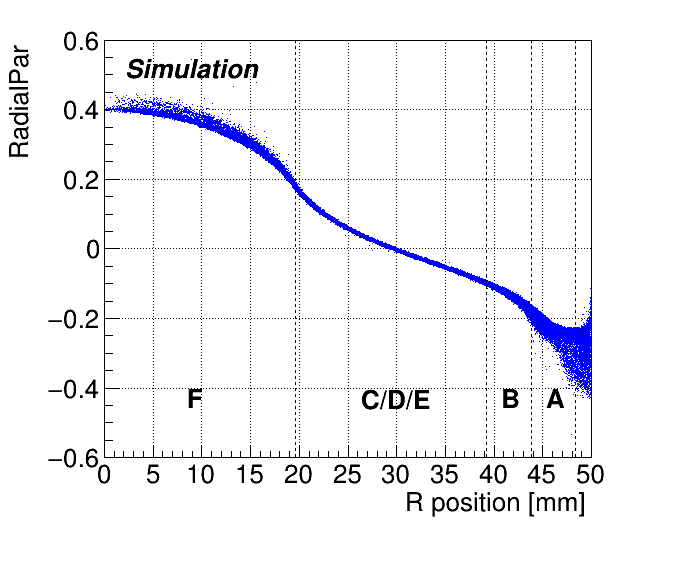

In [28]:
scatter_sim = ROOplot(_xlabel="R position [mm]", _ylabel="RadialPar", _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-0.6, _yhigh=0.6)
scatter_sim.createScatter(np.sqrt( (RQs['sim']['X']*1e3)**2 + (RQs['sim']['Y']*1e3)**2 ), RQs['sim']['RadialPar'])
scatter_sim.draw("AP", "P ")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{Simulation}"
latex.DrawLatex(0.18, 0.9, text)

latex.DrawLatex(0.27, 0.32, "F")
latex.DrawLatex(0.52, 0.32, "C/D/E")
latex.DrawLatex(0.72, 0.32, "B")
latex.DrawLatex(0.785, 0.32, "A")

lineF = ROOT.TLine(19.592, -0.6, 19.592, 0.6)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -0.6, 39.192, 0.6)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -0.6, 43.818, 0.6)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -0.6, 48.3, 0.6)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

line1 = ROOT.TLine(0, 0.07, 50, 0.07)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(1)
line1.SetLineWidth(1)
#line1.Draw("same")

line2 = ROOT.TLine(0, -0.07, 50, -0.07)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(1)
line2.SetLineWidth(1)
#line2.Draw("same")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


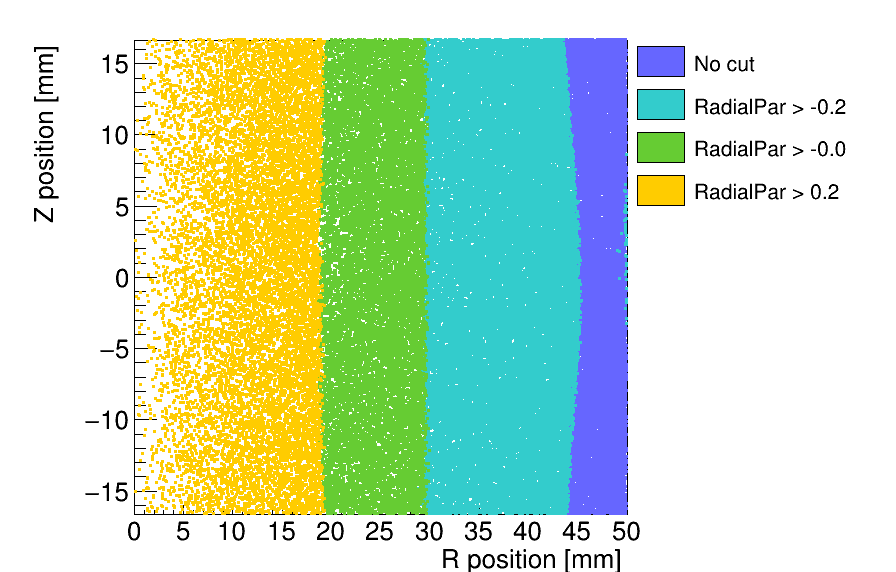

In [21]:
scatter_sim = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _rightMargin=0.3, _leftMargin=0.15, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=33.33/2)

scatter_sim.createScatter(np.sqrt( (RQs['sim']['X']*1e3)**2 + (RQs['sim']['Y']*1e3)**2 ), RQs['sim']['Z']*1e3, color = ROOT.kBlue-7, size = 0.4, label = "No cut")

cut = np.array(RQs['sim']['RadialPar']) > -0.2
scatter_sim.createScatter(np.sqrt( (RQs['sim']['X'][cut]*1e3)**2 + (RQs['sim']['Y'][cut]*1e3)**2 ), RQs['sim']['Z'][cut]*1e3, color = ROOT.kCyan-3, size = 0.4, label = "RadialPar > -0.2")

cut = np.array(RQs['sim']['RadialPar']) > 0
scatter_sim.createScatter(np.sqrt( (RQs['sim']['X'][cut]*1e3)**2 + (RQs['sim']['Y'][cut]*1e3)**2 ), RQs['sim']['Z'][cut]*1e3, color = ROOT.kSpring-5, size = 0.4, label = "RadialPar > -0.0")

cut = np.array(RQs['sim']['RadialPar']) > 0.2
scatter_sim.createScatter(np.sqrt( (RQs['sim']['X'][cut]*1e3)**2 + (RQs['sim']['Y'][cut]*1e3)**2 ), RQs['sim']['Z'][cut]*1e3, color = ROOT.kOrange, size = 0.4, label = "RadialPar > 0.2")
scatter_sim.draw("AP", "P ")
graphs = scatter_sim.getGraphs()

legend = ROOT.TLegend(0.7, 0.63, 1.0, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


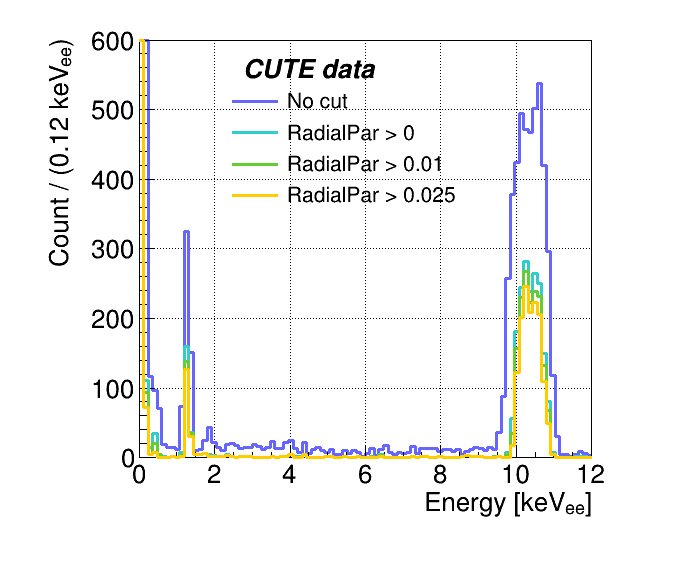

In [262]:
bins_start, bins_end, nbins = 0, 12, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist_data = ROOplot(_xlabel="Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Count / (" + str(binwidth) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})", _leftMargin=0.2, _ylim=True, _ylow=0, _yhigh=600)

hist_data.createHist(RQs['data']['calib_PTOFamps'], bins_start, bins_end, nbins, color=ROOT.kBlue-7, label="No cut")

cut = RQs['data']['RadialPar'] > 0
hist_data.createHist(RQs['data']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kCyan-3, label="RadialPar > 0")

cut = RQs['data']['RadialPar'] > 0.01
hist_data.createHist(RQs['data']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kSpring-5, label="RadialPar > 0.01")

cut = RQs['data']['RadialPar'] > 0.025
hist_data.createHist(RQs['data']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kOrange, label="RadialPar > 0.025")

graphs = hist_data.getGraphs()
hist_data.draw(grid=True)

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{CUTE data}"
latex.DrawLatex(0.35, 0.9, text)

legend = ROOT.TLegend(0.32, 0.63, 0.69, 0.85)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


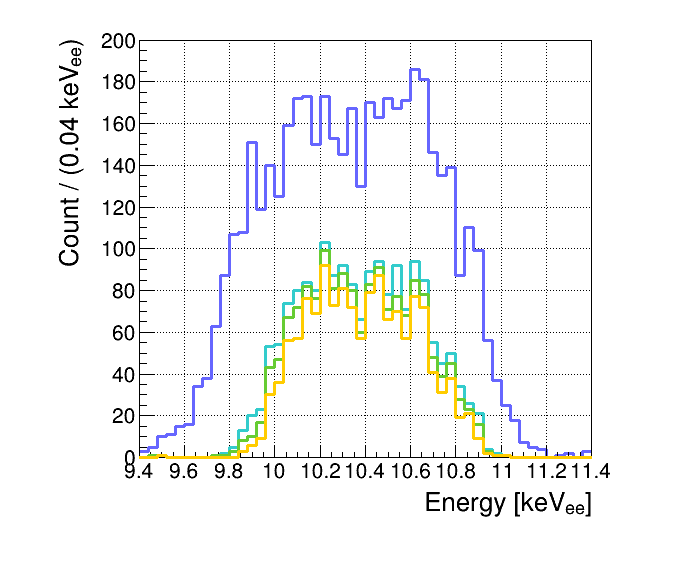

In [263]:
bins_start, bins_end, nbins = 9.4, 11.4, 50
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist_data = ROOplot(_xlabel="Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Count / (" + str(binwidth) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})", 
                     _leftMargin=0.2, _ylim=True, _ylow=0, _yhigh=200, _labelsize=0.04)

hist_data.createHist(RQs['data']['calib_PTOFamps'], bins_start, bins_end, nbins, color=ROOT.kBlue-7, label="No cut")

cut = RQs['data']['RadialPar'] > 0
hist_data.createHist(RQs['data']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kCyan-3, label="RadialPar > 0")

cut = RQs['data']['RadialPar'] > 0.01
hist_data.createHist(RQs['data']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kSpring-5, label="RadialPar > 0.01")

cut = RQs['data']['RadialPar'] > 0.025
hist_data.createHist(RQs['data']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kOrange, label="RadialPar > 0.025")

graphs = hist_data.getGraphs()
hist_data.draw(grid=True)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


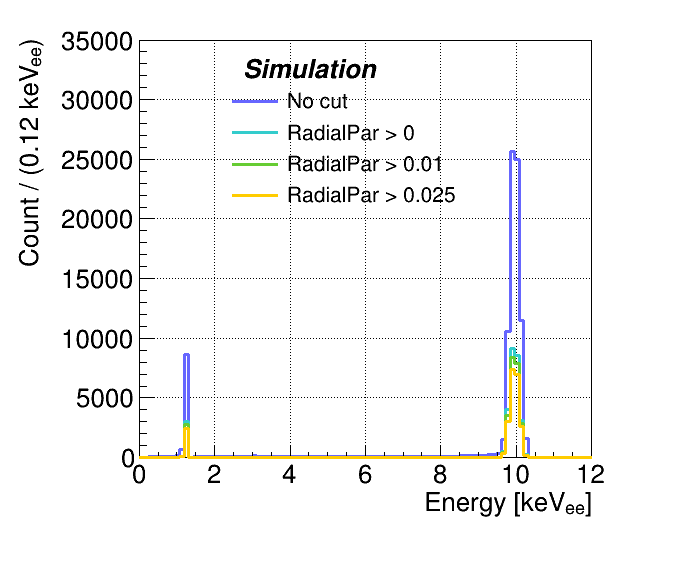

In [264]:
bins_start, bins_end, nbins = 0, 12, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist_sim = ROOplot(_xlabel="Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Count / (" + str(binwidth) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})", _leftMargin=0.2, _ylim=True, _ylow=0, _yhigh=35000)

hist_sim.createHist(RQs['sim']['calib_PTOFamps'], bins_start, bins_end, nbins, color=ROOT.kBlue-7, label="No cut")

cut = RQs['sim']['RadialPar'] > 0
hist_sim.createHist(RQs['sim']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kCyan-3, label="RadialPar > 0")

cut = RQs['sim']['RadialPar'] > 0.01
hist_sim.createHist(RQs['sim']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kSpring-5, label="RadialPar > 0.01")

cut = RQs['sim']['RadialPar'] > 0.025
hist_sim.createHist(RQs['sim']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kOrange, label="RadialPar > 0.025")

graphs = hist_data.getGraphs()
hist_sim.draw(grid=True)

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{Simulation}"
latex.DrawLatex(0.35, 0.9, text)

legend = ROOT.TLegend(0.32, 0.63, 0.69, 0.85)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


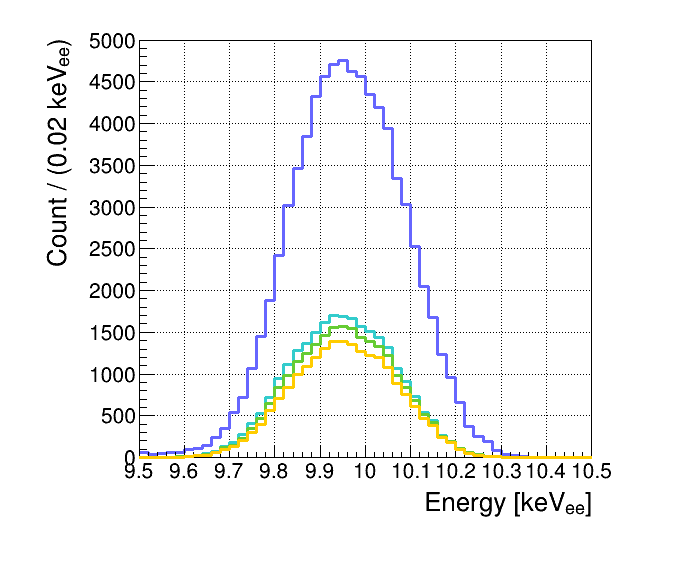

In [265]:
bins_start, bins_end, nbins = 9.5, 10.5, 50
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist_sim = ROOplot(_leftMargin=0.2, _xlabel="Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Count / (" + str(binwidth) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})",
                   _ylim=True, _ylow=0, _yhigh=5000, _labelsize=0.04)

hist_sim.createHist(RQs['sim']['calib_PTOFamps'], bins_start, bins_end, nbins, color=ROOT.kBlue-7, label="No cut")

cut = RQs['sim']['RadialPar'] > 0
hist_sim.createHist(RQs['sim']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kCyan-3, label="RadialPar > 0")

cut = RQs['sim']['RadialPar'] > 0.01
hist_sim.createHist(RQs['sim']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kSpring-5, label="RadialPar > 0.01")

cut = RQs['sim']['RadialPar'] > 0.025
hist_sim.createHist(RQs['sim']['calib_PTOFamps'][cut], bins_start, bins_end, nbins, color=ROOT.kOrange, label="RadialPar > 0.025")

graphs = hist_data.getGraphs()
hist_sim.draw(grid=True)

/tmp/ipykernel_2515536/3303372483.py:73: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  for p, d in zip(passed, data, strict=True): eff.Fill(p, d)


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


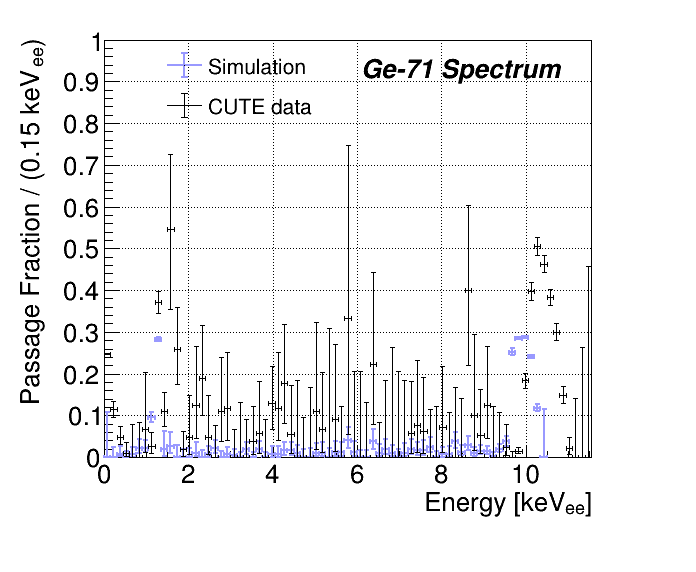

In [266]:
bins_start, bins_end, nbins = 0, 12, 80
binwidth = np.round((bins_end - bins_start) / nbins, 3)

eff = ROOplot(_xlabel="Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Passage Fraction / (" + str(binwidth) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})", _ylim=True, _ylow=0, _yhigh=1)

eff.createEff(RQs['sim']['calib_PTOFamps'], RQs['sim']['RadialPar'] > 0.025, bins_start, bins_end, nbins, color=ROOT.kBlue-9, width=2, label="Simulation")

eff.createEff(RQs['data']['calib_PTOFamps'], RQs['data']['RadialPar'] > 0.025, bins_start, bins_end, nbins, color=ROOT.kBlack, width=1, label="CUTE data")

eff.draw("AP","P ",True)
graphs = eff.getGraphs()

legend = ROOT.TLegend(0.23, 0.78, 0.51, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "lep")
legend.Draw()

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{Ge-71 Spectrum}"
latex.DrawLatex(0.52, 0.9, text)

/tmp/ipykernel_2515536/3303372483.py:73: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  for p, d in zip(passed, data, strict=True): eff.Fill(p, d)


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


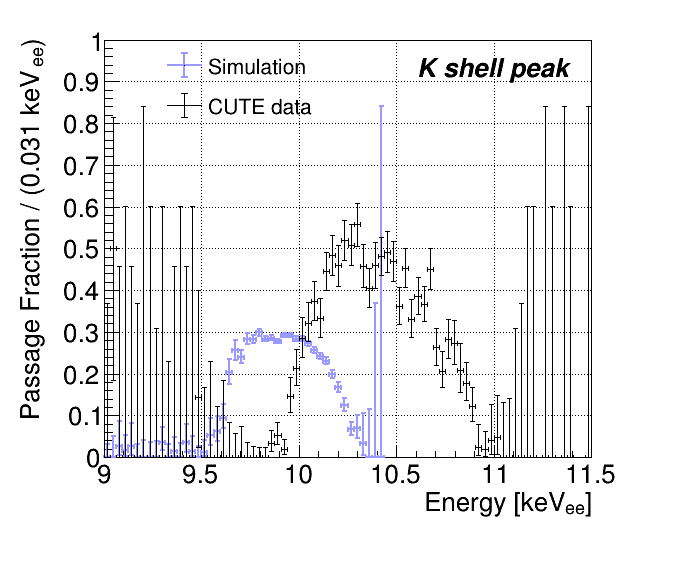

In [267]:
bins_start, bins_end, nbins = 9, 11.5, 80
binwidth = np.round((bins_end - bins_start) / nbins, 3)

eff = ROOplot(_xlabel="Energy [keV_{#kern[-0.3pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Passage Fraction / (" + str(binwidth) + " keV_{#kern[-0.5pt]{#lower[-0.5pt]{ee}}})", 
               _ylim=True, _ylow=0, _yhigh=1, _xlim=True, _xlow=bins_start, _xhigh=bins_end)

eff.createEff(RQs['sim']['calib_PTOFamps'], RQs['sim']['RadialPar'] > 0.025, bins_start, bins_end, nbins, color=ROOT.kBlue-9, width=2, label="Simulation")

eff.createEff(RQs['data']['calib_PTOFamps'], RQs['data']['RadialPar'] > 0.025, bins_start, bins_end, nbins, color=ROOT.kBlack, width=1, label="CUTE data")

eff.draw("AP","P ",True)
graphs = eff.getGraphs()

legend = ROOT.TLegend(0.23, 0.78, 0.51, 0.92)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "lep")
legend.Draw()

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)
text = "#font[72]{K shell peak}"
latex.DrawLatex(0.6, 0.9, text)

In [68]:
thresholds = np.arange(-0.15, 0.3, 0.01)
sim_Kcount = sum(RQs['sim']['Kshell_cut'])
data_Kcount = sum(RQs['data']['Kshell_cut'])

sim_thresh = []
data_thresh = []

for threshold in thresholds:
    sim_thresh.append(sum(RQs['sim']['Kshell_cut'] & (RQs['sim']['RadialPar'] > threshold)))
    data_thresh.append(sum(RQs['data']['Kshell_cut'] & (RQs['data']['RadialPar'] > threshold)))

In [69]:
sim_total = np.full_like(thresholds, sim_Kcount, dtype=int)
data_total = np.full_like(thresholds, data_Kcount, dtype=int)

 FCN=0.385669 FROM MIGRAD    STATUS=CONVERGED     122 CALLS         123 TOTAL
                     EDM=3.67416e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           8.23127e+00   3.40777e-01   6.62372e-07   1.77266e+00
   2  p1           1.41904e-01   5.80258e-03   1.24838e-06   2.25150e-01
   3  p2           2.05419e-01   6.28701e-03   2.65917e-07   1.14354e+00
 FCN=2.53109 FROM MIGRAD    STATUS=CONVERGED      93 CALLS          94 TOTAL
                     EDM=1.00088e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           2.14044e+01   1.32357e+00   9.73690e-07   2.25877e-01
   2  p1           9.38377e-02   5.74965e-03   4.10714e-06   6.00660e-02
   3  p2           1.91644e-01  

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_eff


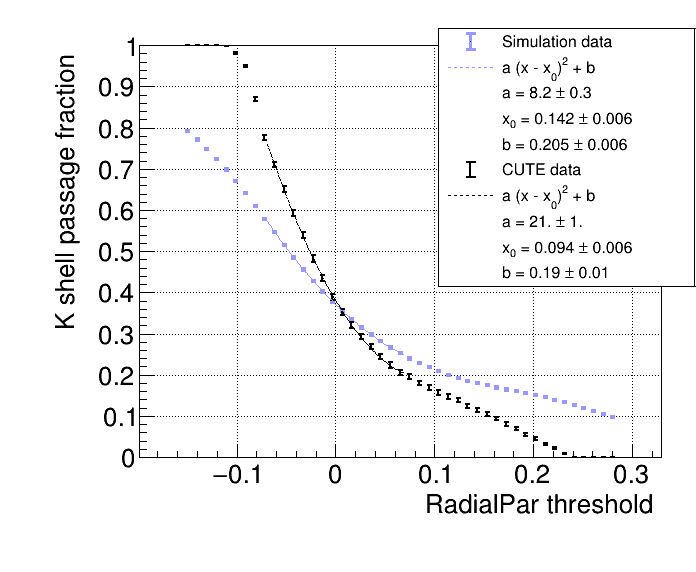

In [70]:
c = ROOT.TCanvas("c_eff", "", 700, 600)
bins_start = thresholds[0] - np.diff(thresholds)[0]/2
bins_end = thresholds[-1] - np.diff(thresholds)[0]/2
nbins = len(thresholds)
bindiff = np.round((bins_end - bins_start) / nbins, 2)

eff_sim = ROOT.TEfficiency("eff_sim", " ; ; ", nbins, bins_start, bins_end)
eff_data = ROOT.TEfficiency("eff_data", " ; ; ", nbins, bins_start, bins_end)

for i, (t, p, tot) in enumerate(zip(thresholds, sim_thresh, sim_total)):
    eff_sim.SetTotalEvents(i+1, int(tot))
    eff_sim.SetPassedEvents(i+1, int(p))

for i, (t, p, tot) in enumerate(zip(thresholds, data_thresh, data_total)):
    eff_data.SetTotalEvents(i+1, int(tot))
    eff_data.SetPassedEvents(i+1, int(p))

g1 = eff_sim.CreateGraph()
for i in range(g1.GetN()):
    g1.SetPointEXlow(i, 0)
    g1.SetPointEXhigh(i, 0)
    
g1.SetLineColor(ROOT.kBlue-9)
g1.SetLineWidth(3)
g1.GetXaxis().SetTitle("RadialPar threshold")
g1.GetYaxis().SetTitle(f"K shell passage fraction")
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
g1.SetMaximum(1)
g1.SetMinimum(0)

g2 = eff_data.CreateGraph()
for i in range(g2.GetN()):
    g2.SetPointEXlow(i, 0)
    g2.SetPointEXhigh(i, 0)
    
g2.SetLineColor(ROOT.kBlack)
g2.SetLineWidth(2)

f1 = ROOT.TF1("f", "[0]*pow(x - [1], 2) + [2]", -0.07, 0.07)
f1.SetParameters(7.7395, 0.15070, 0.20364)
f1.SetParLimits(0, 0, 1e3)
f1.SetParLimits(1, 0, 0.2)
f1.SetLineColor(ROOT.kBlue-9)
f1.SetLineStyle(2)
f1.SetLineWidth(1)
g1.Fit(f1, "", "", -0.07, 0.07)

a1  = f1.GetParameter(0)
a1_err = f1.GetParError(0)
x01 = f1.GetParameter(1)
x01_err = f1.GetParError(1)
b1  = f1.GetParameter(2)
b1_err = f1.GetParError(2)

f2 = ROOT.TF1("f", "[0]*pow(x - [1], 2) + [2]", -0.07, 0.07)
f2.SetParameters(20.792272, 0.09737, 0.196625) 
f2.SetParLimits(0, 0, 1e3) 
f2.SetParLimits(1, 0, 0.2) 
f2.SetLineColor(ROOT.kBlack)
f2.SetLineStyle(2)
f2.SetLineWidth(1)
g2.Fit(f2, "", "", -0.07, 0.07)

a2  = f2.GetParameter(0)
a2_err = f2.GetParError(0)
x02 = f2.GetParameter(1)
x02_err = f2.GetParError(1)
b2  = f2.GetParameter(2)
b2_err = f2.GetParError(2)

g1.Draw("AP")
g2.Draw("P SAME")
f1.Draw("SAME")
f2.Draw("SAME")

legend = ROOT.TLegend(0.63, 0.5, 1, 0.95)
legend.SetBorderSize(1)
legend.SetFillStyle(1001)
legend.SetFillColor(ROOT.kWhite)
legend.AddEntry(g1, "Simulation data", "ep")
legend.AddEntry(f1, "a (x - x_{0})^{2} + b", "l")
legend.AddEntry(0, f"a = {a1:.2}" + " #pm " + f"{a1_err:.1}", "")
legend.AddEntry(0, "x_{0}" + f" = {x01:.3}" + " #pm " + f"{x01_err:.1}", "")
legend.AddEntry(0, f"b = {b1:.3}" + " #pm " + f"{b1_err:.1}", "")
legend.AddEntry(g2, "CUTE data", "ep")
legend.AddEntry(f2, "a (x - x_{0})^{2} + b", "l")
legend.AddEntry(0, f"a = 21." + " #pm " + f"1.", "")
legend.AddEntry(0, "x_{0}" + f" = {x02:.2}" + " #pm " + f"{x02_err:.1}", "")
legend.AddEntry(0, f"b = {b2:.2}" + " #pm " + f"{b2_err:.1}", "")
legend.SetTextSize(0.03)

legend.Draw()
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1, 1)

c.Draw()